# Manufacturing Quality Prediction using Polynomial Regression

## Problem Statement

The objective of this project is to investigate how various manufacturing process parameters affect product quality by building a Polynomial Regression model.

The goal is to capture both linear and non-linear relationships between process variables such as temperature, pressure, interaction terms, and derived manufacturing metrics to predict the overall Quality Rating of manufactured products.

---

## Dataset Features

### Input Features

1. Temperature (°C)
   - Temperature during the manufacturing process.

2. Pressure (kPa)
   - Applied pressure during production.

3. Temperature × Pressure
   - Interaction term representing the combined effect of temperature and pressure.

4. Material Fusion Metric
   - Derived metric computed using temperature and pressure characteristics.

5. Material Transformation Metric
   - Derived metric representing material transformation behavior.

### Target Variable

Quality Rating
- Overall quality score of the manufactured product.

---

## Project Workflow

1. Data Loading
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Polynomial Feature Engineering
5. Model Building
6. Model Evaluation
7. Residual Analysis
8. Test Prediction
9. Submission File Generation

---

## Machine Learning Algorithm

Polynomial Regression (Degree = 2)

Evaluation Metrics:
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

## Import Required Libraries

In [29]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

##Load Dataset

In [30]:
url1 = 'https://new-assets.ccbp.in/frontend/content/aiml/classical-ml/manufacturing_train_dataset.csv'
url2 = 'https://new-assets.ccbp.in/frontend/content/aiml/classical-ml/manufacturing_test_dataset.csv'

In [31]:
# Load the datasets
train_df = pd.read_csv(url1)
test_df = pd.read_csv(url2)

In [ ]:
train_df.head()

,ID,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric,Quality Rating
0,2534,216.199164,9.621265,2080.109475,47632.706816,1.010551e+07,99.999895
1,1614,178.624483,12.048327,2152.126171,33655.667371,5.699174e+06,100.000000
2,3348,159.225345,16.660873,2652.833232,29977.513751,4.036517e+06,100.000000
3,1118,107.032012,22.092997,2364.657879,22239.454281,1.225655e+06,100.000000
4,3592,125.084376,13.242953,1656.486513,17968.594689,1.956907e+06,100.000000


In [ ]:
test_df.head()

,ID,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric
0,150,299.769401,17.080988,5120.357689,94845.246019,2.693749e+07
1,1026,269.669054,9.618072,2593.696257,73611.140498,1.961062e+07
2,2154,276.213323,11.994665,3313.086346,78019.495966,2.107322e+07
3,721,250.204330,12.383619,3098.435063,64501.284332,1.566319e+07
4,326,191.228113,14.653398,2802.141637,39714.599277,6.992652e+06


## Dataset Information

In [32]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3165 entries, 0 to 3164
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              3165 non-null   int64  
 1   Temperature (°C)                3165 non-null   float64
 2   Pressure (kPa)                  3165 non-null   float64
 3   Temperature x Pressure          3165 non-null   float64
 4   Material Fusion Metric          3165 non-null   float64
 5   Material Transformation Metric  3165 non-null   float64
 6   Quality Rating                  3165 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 173.2 KB


## Missing Values

In [34]:
print(train_df.isnull().sum().sum())
print(test_df.isnull().sum().sum())

0
0


##Duplicate Check

In [35]:
print("Train Duplicates:", train_df.duplicated().sum())
print("Test Duplicates:", test_df.duplicated().sum())

Train Duplicates: 0
Test Duplicates: 0


##Statistical Summary

In [36]:
train_df.describe()

,ID,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric,Quality Rating
count,3165.000000,3165.000000,3165.000000,3165.000000,3165.000000,3.165000e+03,3165.000000
mean,1999.351659,200.104397,14.774039,2942.094763,48125.257590,1.004886e+07,96.350187
std,1140.205988,58.195434,5.755085,1440.503934,23753.534384,7.603949e+06,12.645525
min,1.000000,100.014490,5.003008,513.706875,10156.971955,9.999462e+05,1.000000
25%,1006.000000,151.222759,9.720676,1811.032596,27675.925868,3.457730e+06,99.938033
50%,2009.000000,198.584350,14.734343,2675.475344,44611.452164,7.830956e+06,99.999997
75%,2991.000000,251.673099,19.674128,3902.299335,67986.804058,1.594076e+07,100.000000
max,3956.000000,299.992804,24.999132,7284.290729,102662.613144,2.699783e+07,100.000000


##Correlation Heatmap

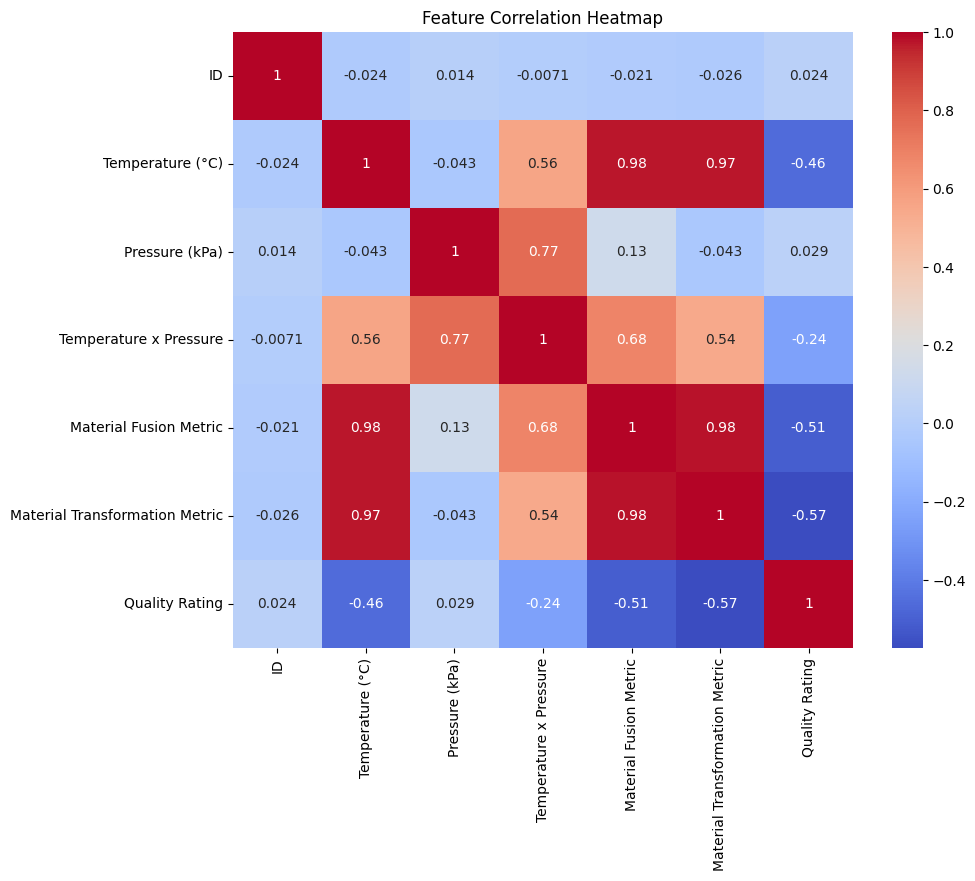

In [37]:
plt.figure(figsize=(10,8))

sns.heatmap(
    train_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")
plt.show()

##Feature & Target Split

In [38]:
X = train_df.drop(columns=["ID", "Quality Rating"])
y = train_df["Quality Rating"]

X_test = test_df.drop(columns=["ID"])

##Train Validation Split

In [39]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

##Polynomial Regression Model

In [40]:
poly_model = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(
        degree=2,
        include_bias=False
    )),
    ("model", LinearRegression())
])

poly_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('poly', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])

##Validation Predictions

In [41]:
y_pred = poly_model.predict(X_val)

##Model Evaluation

In [42]:
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred)

print("MSE :", mse)
print("RMSE:", rmse)
print("R² :", r2)

MSE : 10.111867442452175
RMSE: 3.179916263434019
R² : 0.9170706036082306


##Actual vs Predicted Visualization

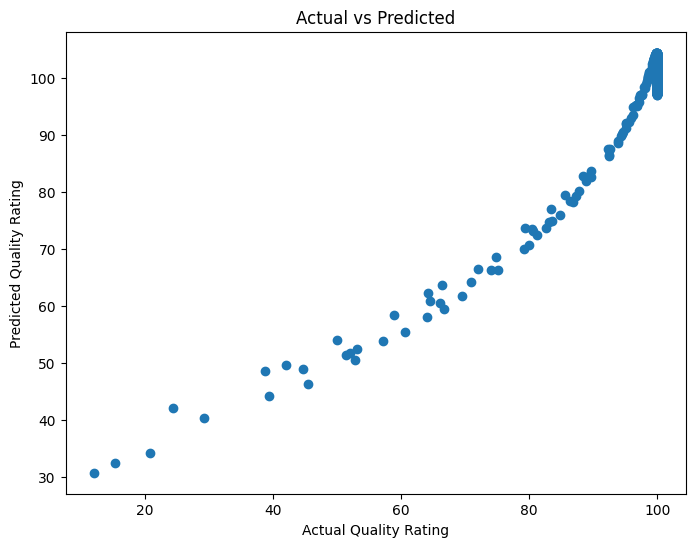

In [43]:
plt.figure(figsize=(8,6))

plt.scatter(y_val, y_pred)

plt.xlabel("Actual Quality Rating")
plt.ylabel("Predicted Quality Rating")
plt.title("Actual vs Predicted")

plt.show()

##Residual Analysis

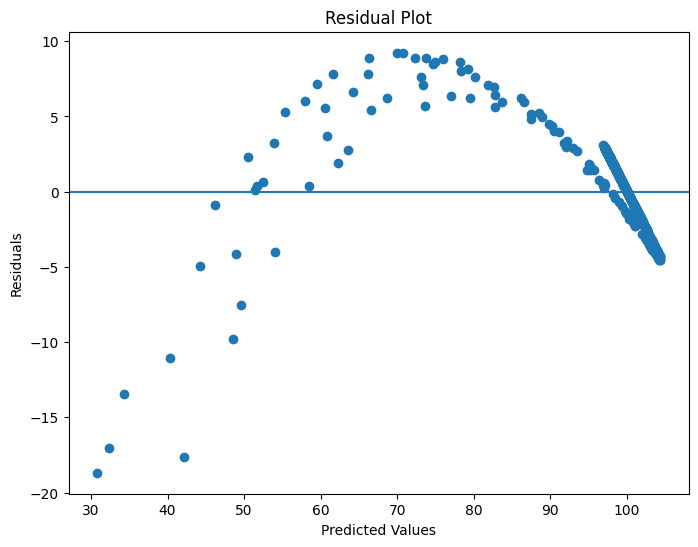

In [44]:
residuals = y_val - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

##Train Final Model on Complete Dataset

In [45]:
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(
        degree=2,
        include_bias=False
    )),
    ("model", LinearRegression())
])

final_model.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('poly', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])

##Test Predictions

In [46]:
test_predictions = final_model.predict(X_test)

In [48]:
output_df = pd.DataFrame({
    "ID": test_df["ID"],
    "Quality Rating": test_predictions
})

output_df.head()

,ID,Quality Rating
0,150,31.582895
1,1026,100.804605
2,2154,95.239437
3,721,103.391171
4,326,98.885889
